In [1]:
import requests

# Download the dataset from a public URL
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz"
output_path = "housing.tgz"

response = requests.get(url, stream=True)
response.raise_for_status()  # Raise an exception for HTTP errors

with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Downloaded {output_path}")

Downloaded housing.tgz


In [2]:
# Verify the download
!ls -l housing.tgz

-rw-r--r-- 1 root root 409488 May 29 11:51 housing.tgz


In [3]:
# Extract the contents of the tgz file
!tar -xzf housing.tgz

In [4]:
# List the contents of the extracted directory (housing) to verify
!ls -l housing/

ls: cannot access 'housing/': No such file or directory


In [5]:
# Unzip the house price dataset
!unzip "/content/house-prices-advanced-regression-techniques.zip" -d "/content/house_prices_dataset"

Archive:  /content/house-prices-advanced-regression-techniques.zip
  inflating: /content/house_prices_dataset/data_description.txt  
  inflating: /content/house_prices_dataset/sample_submission.csv  
  inflating: /content/house_prices_dataset/test.csv  
  inflating: /content/house_prices_dataset/train.csv  


In [6]:
# List the contents of the extracted directory to verify
!ls -l "/content/house_prices_dataset"

total 944
-rw-r--r-- 1 root root  13370 Dec 15  2019 data_description.txt
-rw-r--r-- 1 root root  31939 Dec 15  2019 sample_submission.csv
-rw-r--r-- 1 root root 451405 Dec 15  2019 test.csv
-rw-r--r-- 1 root root 460676 Dec 15  2019 train.csv


In [7]:
# List all files in the current directory to find where 'housing.tgz' contents might have landed
!ls -l

total 2000
-rw-r--r-- 1 root root   203809 May 29 11:30 house-prices-advanced-regression-techniques.zip
drwxr-xr-x 2 root root     4096 May 29 12:15 house_prices_dataset
-rw-r--r-- 1  501 staff 1423529 May  3  2016 housing.csv
-rw-r--r-- 1 root root   409488 May 29 11:51 housing.tgz
drwxr-xr-x 1 root root     4096 May 26 13:25 sample_data


In [8]:
import pandas as pd

# Load the housing.csv file
housing_df = pd.read_csv('housing.csv')

# Display the first few rows and information about the DataFrame
display(housing_df.head())
display(housing_df.info())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the train.csv file from the house_prices_dataset directory
train_df = pd.read_csv('/content/house_prices_dataset/train.csv')

# Display the first few rows and information about the DataFrame to check columns
display(train_df.head())
display(train_df.info())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

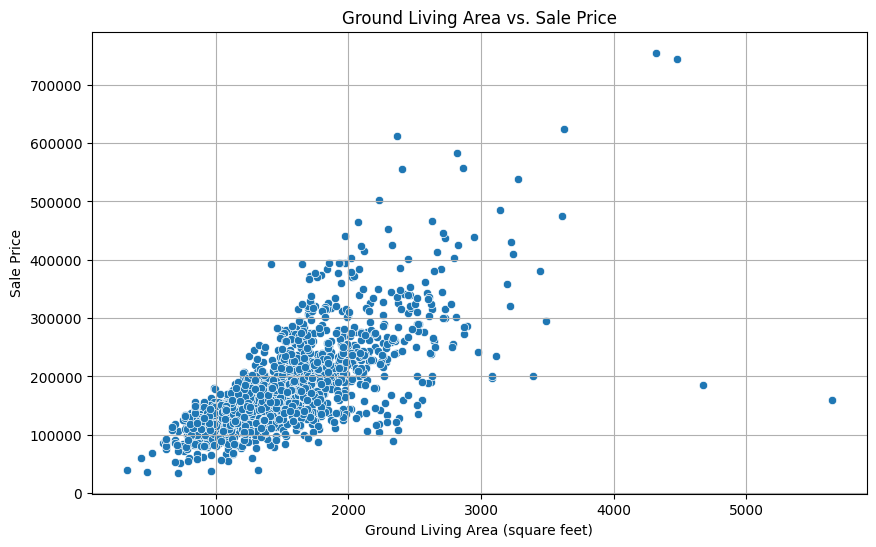

In [10]:
# Create a scatter plot of GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df)
plt.title('Ground Living Area vs. Sale Price')
plt.xlabel('Ground Living Area (square feet)')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Feature Engineering: Create TotalBaths
train_df['TotalBaths'] = train_df['FullBath'] + 0.5 * train_df['HalfBath'] + \
                         train_df['BsmtFullBath'] + 0.5 * train_df['BsmtHalfBath']

# Select features (X) and target (y)
features = ['GrLivArea', 'BedroomAbvGr', 'TotalBaths']
X = train_df[features]
y = train_df['SalePrice']

# Handle missing values (if any) - A simple strategy is to fill with the mean
# In this specific dataset, for the chosen features, there are no missing values, but it's good practice.
X = X.fillna(X.mean())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Model Coefficients: [    94.66424501 -23244.433814    30177.98168689]
Model Intercept: 36976.44834025696
Mean Squared Error (MSE): 2623753007.35
Root Mean Squared Error (RMSE): 51222.58
R-squared (R2): 0.66


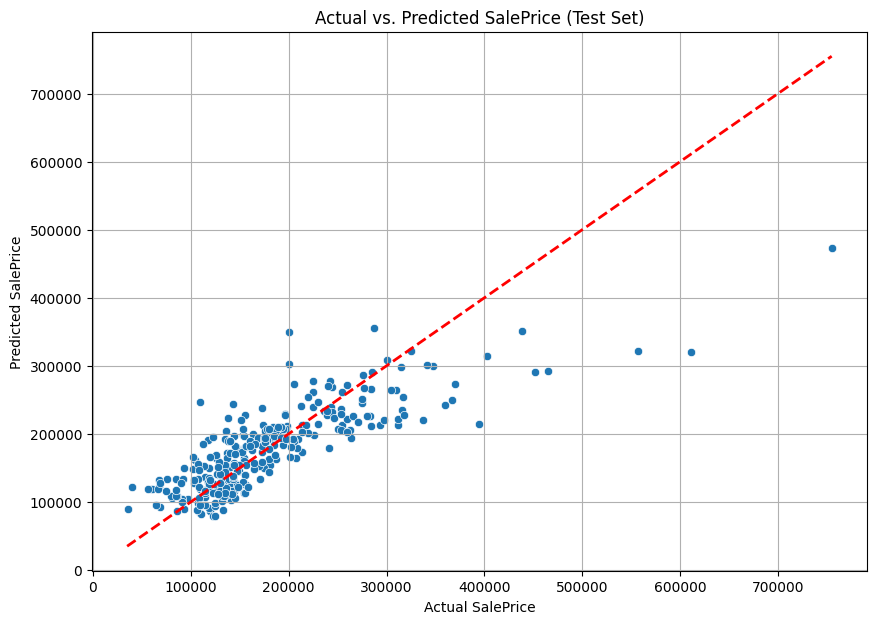

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs. Predicted SalePrice (Test Set)')
plt.grid(True)
plt.show()

In [13]:
# Add 'OverallQual' to the features list
new_features = ['GrLivArea', 'BedroomAbvGr', 'TotalBaths', 'OverallQual']
X_new = train_df[new_features]
y_new = train_df['SalePrice']

# Handle missing values (if any) - Fill with the mean
X_new = X_new.fillna(X_new.mean())

# Split data into training and testing sets for the new model
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Initialize and train the new Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

# Make predictions on the new test set
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model
mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_pred_new)

print("--- Original Model Performance ---")
print(f"Original MSE: {mse:.2f}")
print(f"Original RMSE: {rmse:.2f}")
print(f"Original R-squared: {r2:.2f}")
print("\n--- New Model Performance (with OverallQual) ---")
print(f"New Model Coefficients: {model_new.coef_}")
print(f"New Model Intercept: {model_new.intercept_}")
print(f"New MSE: {mse_new:.2f}")
print(f"New RMSE: {rmse_new:.2f}")
print(f"New R-squared: {r2_new:.2f}")

--- Original Model Performance ---
Original MSE: 2623753007.35
Original RMSE: 51222.58
Original R-squared: 0.66

--- New Model Performance (with OverallQual) ---
New Model Coefficients: [    52.85678038 -10537.45993241  18425.92121469  27677.77679274]
New Model Intercept: -79211.60729953641
New MSE: 1796748973.64
New RMSE: 42388.08
New R-squared: 0.77


In [14]:
from sklearn.model_selection import KFold, cross_val_score

# Define the features for the updated model
cv_features = ['GrLivArea', 'BedroomAbvGr', 'TotalBaths', 'OverallQual']
X_cv = train_df[cv_features]
y_cv = train_df['SalePrice']

# Handle missing values (if any) - Fill with the mean
X_cv = X_cv.fillna(X_cv.mean())

# Initialize the Linear Regression model
cv_model = LinearRegression()

# Set up K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5 folds

# Perform cross-validation for R-squared
r2_scores = cross_val_score(cv_model, X_cv, y_cv, cv=kf, scoring='r2')

# Perform cross-validation for Mean Squared Error (negative because cross_val_score maximizes the score)
mse_scores = -cross_val_score(cv_model, X_cv, y_cv, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print("\n--- Cross-Validation Results (with OverallQual) ---")
print(f"R-squared scores for each fold: {r2_scores}")
print(f"Average R-squared: {np.mean(r2_scores):.2f} (+/- {np.std(r2_scores):.2f})")
print(f"MSE scores for each fold: {mse_scores}")
print(f"Average MSE: {np.mean(mse_scores):.2f} (+/- {np.std(mse_scores):.2f})")
print(f"RMSE scores for each fold: {rmse_scores}")
print(f"Average RMSE: {np.mean(rmse_scores):.2f} (+/- {np.std(rmse_scores):.2f})")


--- Cross-Validation Results (with OverallQual) ---
R-squared scores for each fold: [0.76575325 0.782774   0.50401329 0.77728962 0.77725769]
Average R-squared: 0.72 (+/- 0.11)
MSE scores for each fold: [1.79674897e+09 1.47697773e+09 2.74015899e+09 1.39842163e+09
 1.16424373e+09]
Average MSE: 1715310211.35 (+/- 550970469.30)
RMSE scores for each fold: [42388.0758426  38431.46794363 52346.52793477 37395.47612214
 34121.01601037]
Average RMSE: 40936.51 (+/- 6285.87)


Now, let's use the `model_new` (which includes 'GrLivArea', 'BedroomAbvGr', 'TotalBaths', and 'OverallQual') to predict the `SalePrice` and add these predictions as a new 'feature' (a column) to our `train_df`.

In [15]:
# Define the features used by model_new
prediction_features = ['GrLivArea', 'BedroomAbvGr', 'TotalBaths', 'OverallQual']

# Ensure 'TotalBaths' is created in train_df before prediction if not already present
if 'TotalBaths' not in train_df.columns:
    train_df['TotalBaths'] = train_df['FullBath'] + 0.5 * train_df['HalfBath'] + \
                             train_df['BsmtFullBath'] + 0.5 * train_df['BsmtHalfBath']

# Prepare the data for prediction using the same features as model_new
X_predict = train_df[prediction_features]

# Handle missing values in prediction_features using the mean strategy, similar to training
X_predict = X_predict.fillna(X_predict.mean())

# Generate predictions using the trained model_new
train_df['PredictedSalePrice'] = model_new.predict(X_predict)

# Display the first few rows with the new predicted price column
display(train_df[['GrLivArea', 'BedroomAbvGr', 'TotalBaths', 'OverallQual', 'SalePrice', 'PredictedSalePrice']].head())

,GrLivArea,BedroomAbvGr,TotalBaths,OverallQual,SalePrice,PredictedSalePrice
0,1710,3,3.5,7,208500,237796.269149
1,1262,3,2.5,6,181500,168012.733532
2,1786,3,3.5,7,223500,241813.384458
3,1717,3,2.0,7,140000,210527.384789
4,2198,4,3.5,8,250000,280730.694833
